<a href="https://colab.research.google.com/github/hosseinayoubi/Clustering/blob/main/AAAI2026ClusteringAbdolhosseinAyoubi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Applied Analytics and AI

**Clustering Exercise**  
**Abdolhossein Ayoubi, 2601615**  
Master's Degree Programme in Smart Industry

I used the Mall Customers dataset for this exercise. My goal was simple: find natural customer groups with K-Means and explain what those groups mean.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

## 1. Load and check the data

I load the CSV directly from my GitHub repository. I also check the size, missing values, and duplicates before doing any clustering.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/hosseinayoubi/Clustering/main/Mall_Customers.csv"

df = pd.read_csv(DATA_URL)

print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df.head()

Shape: (200, 5)
Missing values: 0
Duplicate rows: 0


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].describe().round(1)

,Age,Annual Income (k$),Spending Score (1-100)
count,200.0,200.0,200.0
mean,38.8,60.6,50.2
std,14.0,26.3,25.8
min,18.0,15.0,1.0
25%,28.8,41.5,34.8
50%,36.0,61.5,50.0
75%,49.0,78.0,73.0
max,70.0,137.0,99.0


## 2. Prepare the features

I use **Annual Income** and **Spending Score** for K-Means. I leave out CustomerID because it is only an identifier. I standardize the two features so that both have a fair effect on the distance calculation.

In [4]:
features = ["Annual Income (k$)", "Spending Score (1-100)"]
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## 3. Choose the number of clusters

I first check the Elbow Method. Then I use the Silhouette Score as a second check.

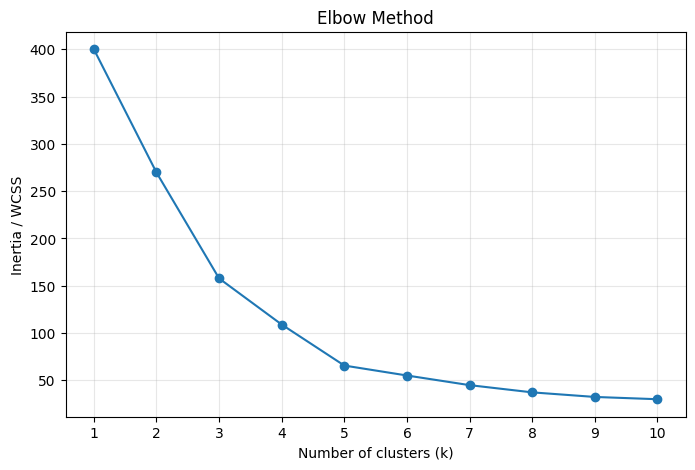

In [5]:
inertias = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia / WCSS")
plt.title("Elbow Method")
plt.xticks(range(1, 11))
plt.grid(alpha=0.3)
plt.show()

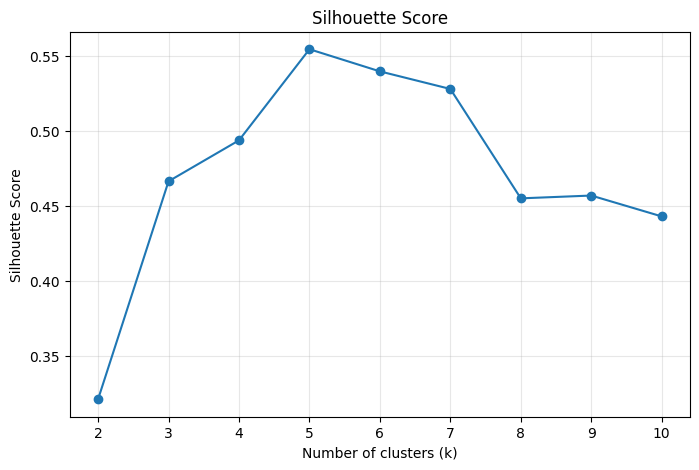

Best k: 5
Best silhouette score: 0.555


In [6]:
scores = {}

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    scores[k] = silhouette_score(X_scaled, labels)

plt.figure(figsize=(8, 5))
plt.plot(list(scores.keys()), list(scores.values()), marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.xticks(range(2, 11))
plt.grid(alpha=0.3)
plt.show()

best_k = max(scores, key=scores.get)
print("Best k:", best_k)
print("Best silhouette score:", round(scores[best_k], 3))

The elbow is around five clusters, and the best silhouette score is also at **k = 5**. I use five clusters for the final model.

## 4. Run K-Means

In [7]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["Raw Cluster"] = kmeans.fit_predict(X_scaled)

centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
)
centers

,Annual Income (k$),Spending Score (1-100)
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


K-Means cluster numbers are arbitrary, so I rename them in a simple order that is easier to read in the report.

In [8]:
def cluster_name(row):
    income = row["Annual Income (k$)"]
    spending = row["Spending Score (1-100)"]

    if income < 40 and spending < 50:
        return "Low income / low spending"
    if income < 40 and spending >= 50:
        return "Low income / high spending"
    if income < 70:
        return "Medium income / medium spending"
    if spending < 50:
        return "High income / low spending"
    return "High income / high spending"

name_to_segment = {
    "Low income / low spending": 1,
    "Low income / high spending": 2,
    "Medium income / medium spending": 3,
    "High income / low spending": 4,
    "High income / high spending": 5
}

raw_to_segment = {}
for raw_cluster, row in centers.iterrows():
    raw_to_segment[raw_cluster] = name_to_segment[cluster_name(row)]

df["Segment"] = df["Raw Cluster"].map(raw_to_segment)
df["Segment Name"] = df["Segment"].map({v: k for k, v in name_to_segment.items()})

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Raw Cluster,Segment,Segment Name
0,1,Male,19,15,39,4,1,Low income / low spending
1,2,Male,21,15,81,2,2,Low income / high spending
2,3,Female,20,16,6,4,1,Low income / low spending
3,4,Female,23,16,77,2,2,Low income / high spending
4,5,Female,31,17,40,4,1,Low income / low spending


## 5. Results

In [9]:
summary = (
    df.groupby(["Segment", "Segment Name"])
      .agg(
          Customers=("CustomerID", "count"),
          Average_Age=("Age", "mean"),
          Average_Income=("Annual Income (k$)", "mean"),
          Average_Spending=("Spending Score (1-100)", "mean")
      )
      .reset_index()
)

summary["Share (%)"] = summary["Customers"] / len(df) * 100
summary.round(1)

,Segment,Segment Name,Customers,Average_Age,Average_Income,Average_Spending,Share (%)
0,1,Low income / low spending,23,45.2,26.3,20.9,11.5
1,2,Low income / high spending,22,25.3,25.7,79.4,11.0
2,3,Medium income / medium spending,81,42.7,55.3,49.5,40.5
3,4,High income / low spending,35,41.1,88.2,17.1,17.5
4,5,High income / high spending,39,32.7,86.5,82.1,19.5


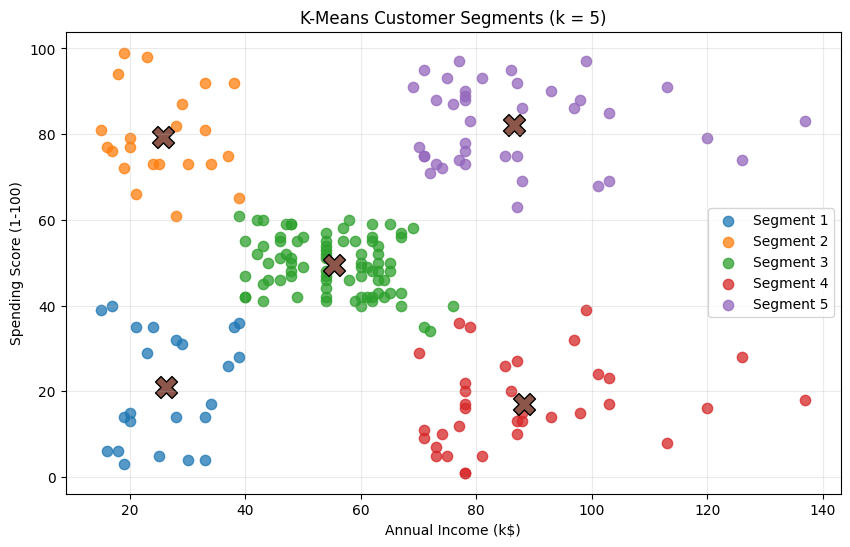

In [10]:
plt.figure(figsize=(10, 6))

for segment in range(1, 6):
    part = df[df["Segment"] == segment]
    plt.scatter(
        part["Annual Income (k$)"],
        part["Spending Score (1-100)"],
        s=55,
        alpha=0.75,
        label=f"Segment {segment}"
    )

centers_final = df.groupby("Segment")[features].mean()
plt.scatter(
    centers_final["Annual Income (k$)"],
    centers_final["Spending Score (1-100)"],
    marker="X",
    s=250,
    edgecolor="black",
    linewidth=1
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means Customer Segments (k = 5)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

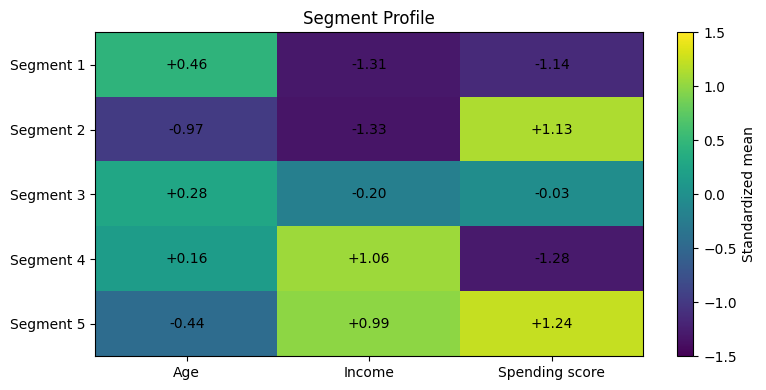

In [11]:
profile_features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
profile_scaler = StandardScaler()
profile_scaled = profile_scaler.fit_transform(df[profile_features])

profile_df = pd.DataFrame(profile_scaled, columns=profile_features)
profile_df["Segment"] = df["Segment"].values
profile = profile_df.groupby("Segment")[profile_features].mean()

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(profile.values, aspect="auto", vmin=-1.5, vmax=1.5)

ax.set_xticks(range(3))
ax.set_xticklabels(["Age", "Income", "Spending score"])
ax.set_yticks(range(5))
ax.set_yticklabels([f"Segment {i}" for i in range(1, 6)])

for i in range(profile.shape[0]):
    for j in range(profile.shape[1]):
        ax.text(j, i, f"{profile.iloc[i, j]:+.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax, label="Standardized mean")
plt.title("Segment Profile")
plt.tight_layout()
plt.show()

## 6. My interpretation

The five groups are easy to understand:

- **Segment 1:** lower income and lower spending.
- **Segment 2:** lower income but high spending.
- **Segment 3:** the largest group, close to the middle for both income and spending.
- **Segment 4:** high income but low spending. This group may have room for better engagement.
- **Segment 5:** high income and high spending. This looks like the strongest customer group in this dataset.

The result makes sense visually, and the silhouette score of about **0.555** supports the five-cluster solution. I kept the exercise focused on K-Means. SOM was optional, so I did not use it here.

## Conclusion

K-Means gave me five clear customer segments from only two simple variables. The analysis shows how clustering can turn a small customer dataset into groups that are easier to understand and discuss. For a real company, I would use more customer behavior data before making marketing decisions.